# Demonstration of Panther-EM coordinate systems

For the SVD process to work with in-plane rotational symmetry, we need the projection coordinate system to be in a polar coordinate system rather than the usual Cartesian coordinates. This notebook demonstrates the three coordinate transforms implemented in `panther_em.coordinates`:

- **`StandardPolarTransform`** -- the ordinary polar grid, uniform spacing in both radius and angle.
- **`OffsetPolarTransform`** -- identical to standard polar, except every other radial ring is angularly offset by half a step, improving spatial coverage.
- **`SpiralPolarTransform`** -- non-uniform (near-linear-to-sqrt) radial spacing plus a continuous angular twist per radial step, giving more uniform areal sampling density both near the center and near the edges.

Structure of this notebook:
1. Coordinate grid sampling on a 64x64 grid, plotted as scatter points.
2. Warp transforms applied to a test image (`skimage.data.camera`), with resultant plots.
3. Round-trip reconstructions plus difference images.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data

from panther_em.coordinates import (
    OffsetPolarTransform,
    SpiralPolarTransform,
    StandardPolarTransform,
)
from panther_em.coordinates.offset_polar import (
    forward_offset_polar_to_cartesian_mapping,
)
from panther_em.coordinates.spiral_polar import (
    forward_spiral_polar_to_cartesian_mapping,
)
from panther_em.coordinates.standard_polar import forward_polar_to_cartesian_mapping

## 1. Coordinate grid sampling on a grid

Each transform module exposes a `forward_*_to_cartesian_mapping` function that maps integer `(radius_idx, angle_idx)` polar-index coordinates directly to Cartesian `(row, col)` coordinates. Plotting these as scatter points shows how each system distributes its sample points over a 64x64 image.

`num_angle`/`num_radius` are kept small here purely so the scatter plot stays legible -- the actual decomposition pipeline uses much finer grids.

In [2]:
grid_shape = (128, 128)
grid_center = (grid_shape[0] / 2 - 0.5, grid_shape[1] / 2 - 0.5)
grid_radius = grid_shape[0] / 2

num_angle_grid = 180
num_radius_grid = 128

print(f"grid_shape={grid_shape}, center={grid_center}, radius={grid_radius}")
print(f"num_angle_grid={num_angle_grid}, num_radius_grid={num_radius_grid}")

grid_shape=(128, 128), center=(63.5, 63.5), radius=64.0
num_angle_grid=180, num_radius_grid=128


In [3]:
radius_idx = np.arange(num_radius_grid)
angle_idx = np.arange(num_angle_grid)
rr, aa = np.meshgrid(radius_idx, angle_idx, indexing="ij")
polar_index_coords = np.column_stack((rr.ravel(), aa.ravel())).astype(float)
polar_index_coords.shape

(23040, 2)

In [4]:
cartesian_standard = forward_polar_to_cartesian_mapping(
    polar_index_coords,
    num_angle=num_angle_grid,
    num_radius=num_radius_grid,
    max_radius=grid_radius,
    center=grid_center,
)

cartesian_offset = forward_offset_polar_to_cartesian_mapping(
    polar_index_coords,
    num_angle=num_angle_grid,
    num_radius=num_radius_grid,
    max_radius=grid_radius,
    center=grid_center,
)

cartesian_spiral = forward_spiral_polar_to_cartesian_mapping(
    polar_index_coords,
    num_angle=num_angle_grid,
    num_radius=num_radius_grid,
    max_radius=grid_radius,
    center=grid_center,
)

In [5]:
radial_color = polar_index_coords[:, 1]

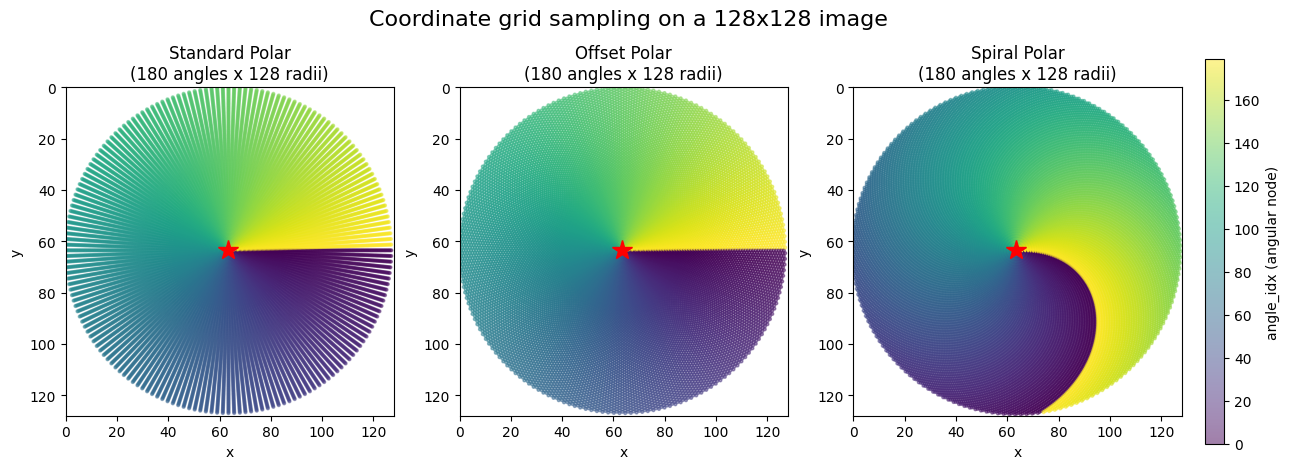

In [6]:
grids = [
    ("Standard Polar", cartesian_standard),
    ("Offset Polar", cartesian_offset),
    ("Spiral Polar", cartesian_spiral),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (title, coords) in zip(axes, grids, strict=False):
    sc = ax.scatter(
        coords[:, 1], coords[:, 0], s=4, alpha=0.5, c=radial_color, cmap="viridis"
    )
    ax.plot(grid_center[1], grid_center[0], "r*", markersize=15)
    ax.set_xlim(0, grid_shape[1])
    ax.set_ylim(grid_shape[0], 0)
    ax.set_aspect("equal")
    ax.set_title(f"{title}\n({num_angle_grid} angles x {num_radius_grid} radii)")
    ax.set_xlabel("x")
    ax.set_ylabel("y")

fig.suptitle(
    f"Coordinate grid sampling on a {grid_shape[0]}x{grid_shape[1]} image", fontsize=16
)
fig.colorbar(sc, ax=axes, fraction=0.02, pad=0.02, label="angle_idx (angular node)")
plt.show()

## 2. Warp transforms applied to a test image

Using `skimage.data.camera()` as the test image, build each transform via `.from_image(...)`, passing the same `num_angle` and `radius` (the full image diagonal, so the square image's corners are covered rather than just the inscribed circle) so the resulting polar-space images are directly comparable. The class-based `to_transform_space` method dispatches to `scikit-image`'s `warp` internally (see `CoordinateTransform` in `transform_base.py`), so no manual `warp(...)` calls are needed here.

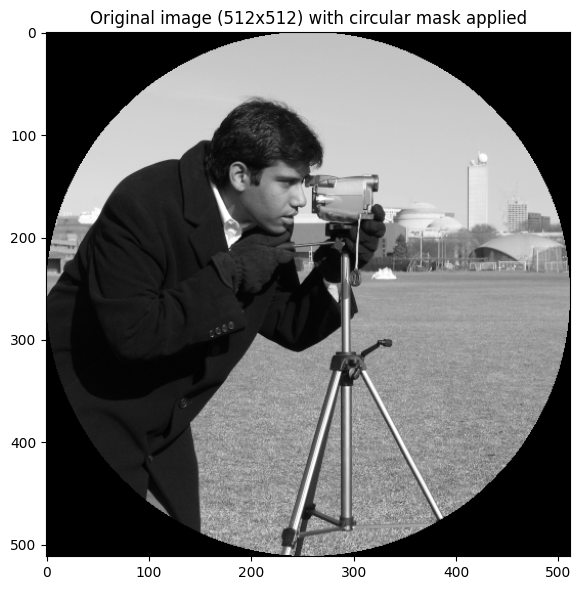

In [7]:
image = data.camera().astype(np.float32) / 255.0
image_shape = image.shape

# apply circular mask to image to avoid artifacts from corners
y, x = np.ogrid[: image_shape[0], : image_shape[1]]
y = y - image_shape[0] / 2 + 0.5
x = x - image_shape[1] / 2 + 0.5
mask = np.sqrt(x**2 + y**2) <= (image_shape[0] / 2)
mask_small = np.sqrt(x**2 + y**2) <= (image_shape[0] / 2) - 4  # smaller margin
image[~mask] = 0

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap="gray")
plt.title(
    f"Original image ({image_shape[0]}x{image_shape[1]}) with circular mask applied"
)
plt.tight_layout()
plt.show()

In [8]:
num_radius = 512
num_angle = 720

standard_transform = StandardPolarTransform.from_image(
    image_shape, num_angle=num_angle, num_radius=num_radius
)
offset_transform = OffsetPolarTransform.from_image(
    image_shape, num_angle=num_angle, num_radius=num_radius
)
spiral_transform = SpiralPolarTransform.from_image(
    image_shape,
    num_angle=num_angle,
    num_radius=num_radius,
)

transforms = {
    "Standard Polar": standard_transform,
    "Offset Polar": offset_transform,
    "Spiral Polar": spiral_transform,
}

print(f"Original image shape: {image_shape}")
for name, t in transforms.items():
    print(f"{name}: polar_shape={t.polar_shape}")

Original image shape: (512, 512)
Standard Polar: polar_shape=(720, 512)
Offset Polar: polar_shape=(720, 512)
Spiral Polar: polar_shape=(720, 512)


In [9]:
polar_images = {
    name: t.to_transform_space(image, preserve_energy=True)
    for name, t in transforms.items()
}
{name: img.shape for name, img in polar_images.items()}

{'Standard Polar': (720, 512),
 'Offset Polar': (720, 512),
 'Spiral Polar': (720, 512)}

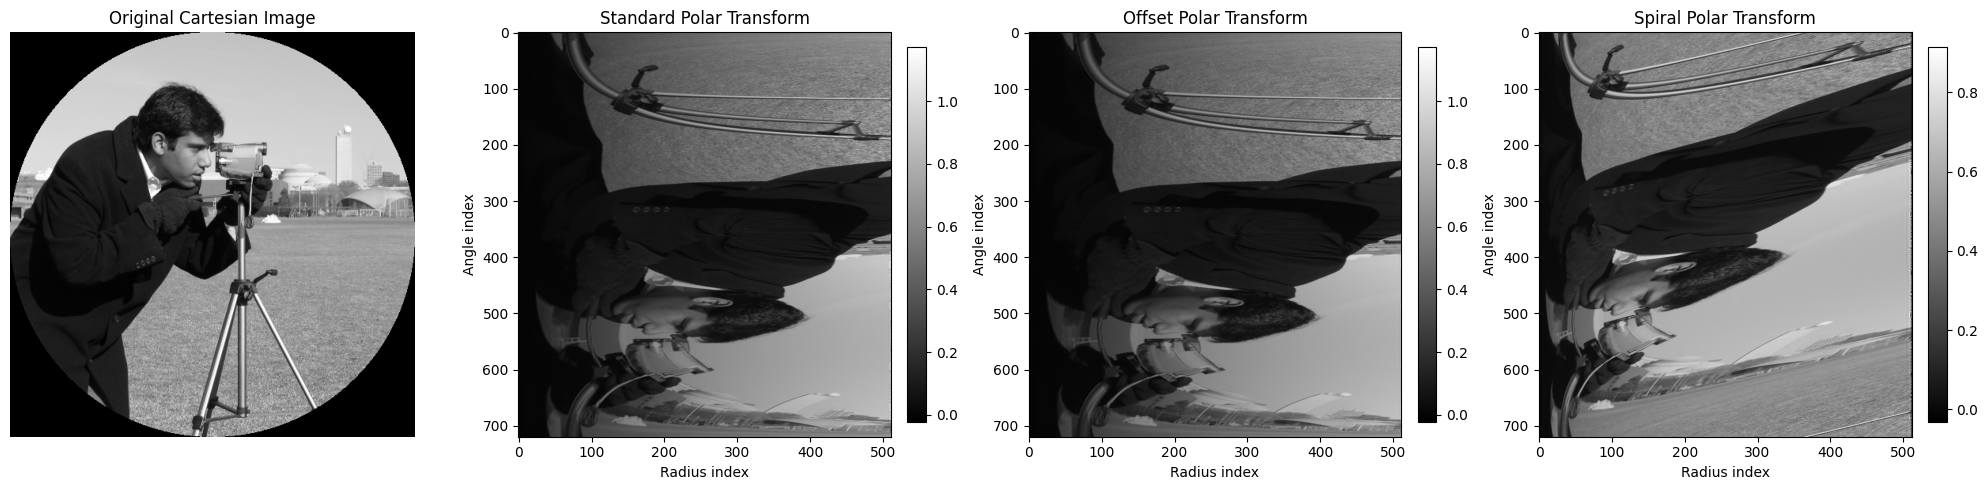

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image, cmap="gray")
axes[0].set_title("Original Cartesian Image")
axes[0].axis("off")

for ax, (name, polar_image) in zip(axes[1:], polar_images.items(), strict=False):
    im = ax.imshow(polar_image, cmap="gray", aspect="auto")
    ax.set_title(f"{name} Transform")
    ax.set_xlabel("Radius index")
    ax.set_ylabel("Angle index")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## 3. Round-trip reconstruction and difference images

Applying `to_cartesian` to each polar-space image recovers a Cartesian reconstruction. Comparing against the original shows how well each coordinate system's interpolation preserves image content. `preserve_energy=True` on both the forward and inverse warp keeps the Jacobian scaling applied in step 2 consistent -- the inverse call divides back out what the forward call multiplied in.

In [11]:
reconstructions = {
    name: t.to_cartesian(polar_images[name], preserve_energy=True)
    for name, t in transforms.items()
}
differences = {name: image - reconstructions[name] for name in transforms}
for name, diff in differences.items():
    differences[name] = np.where(mask_small, diff, 0)

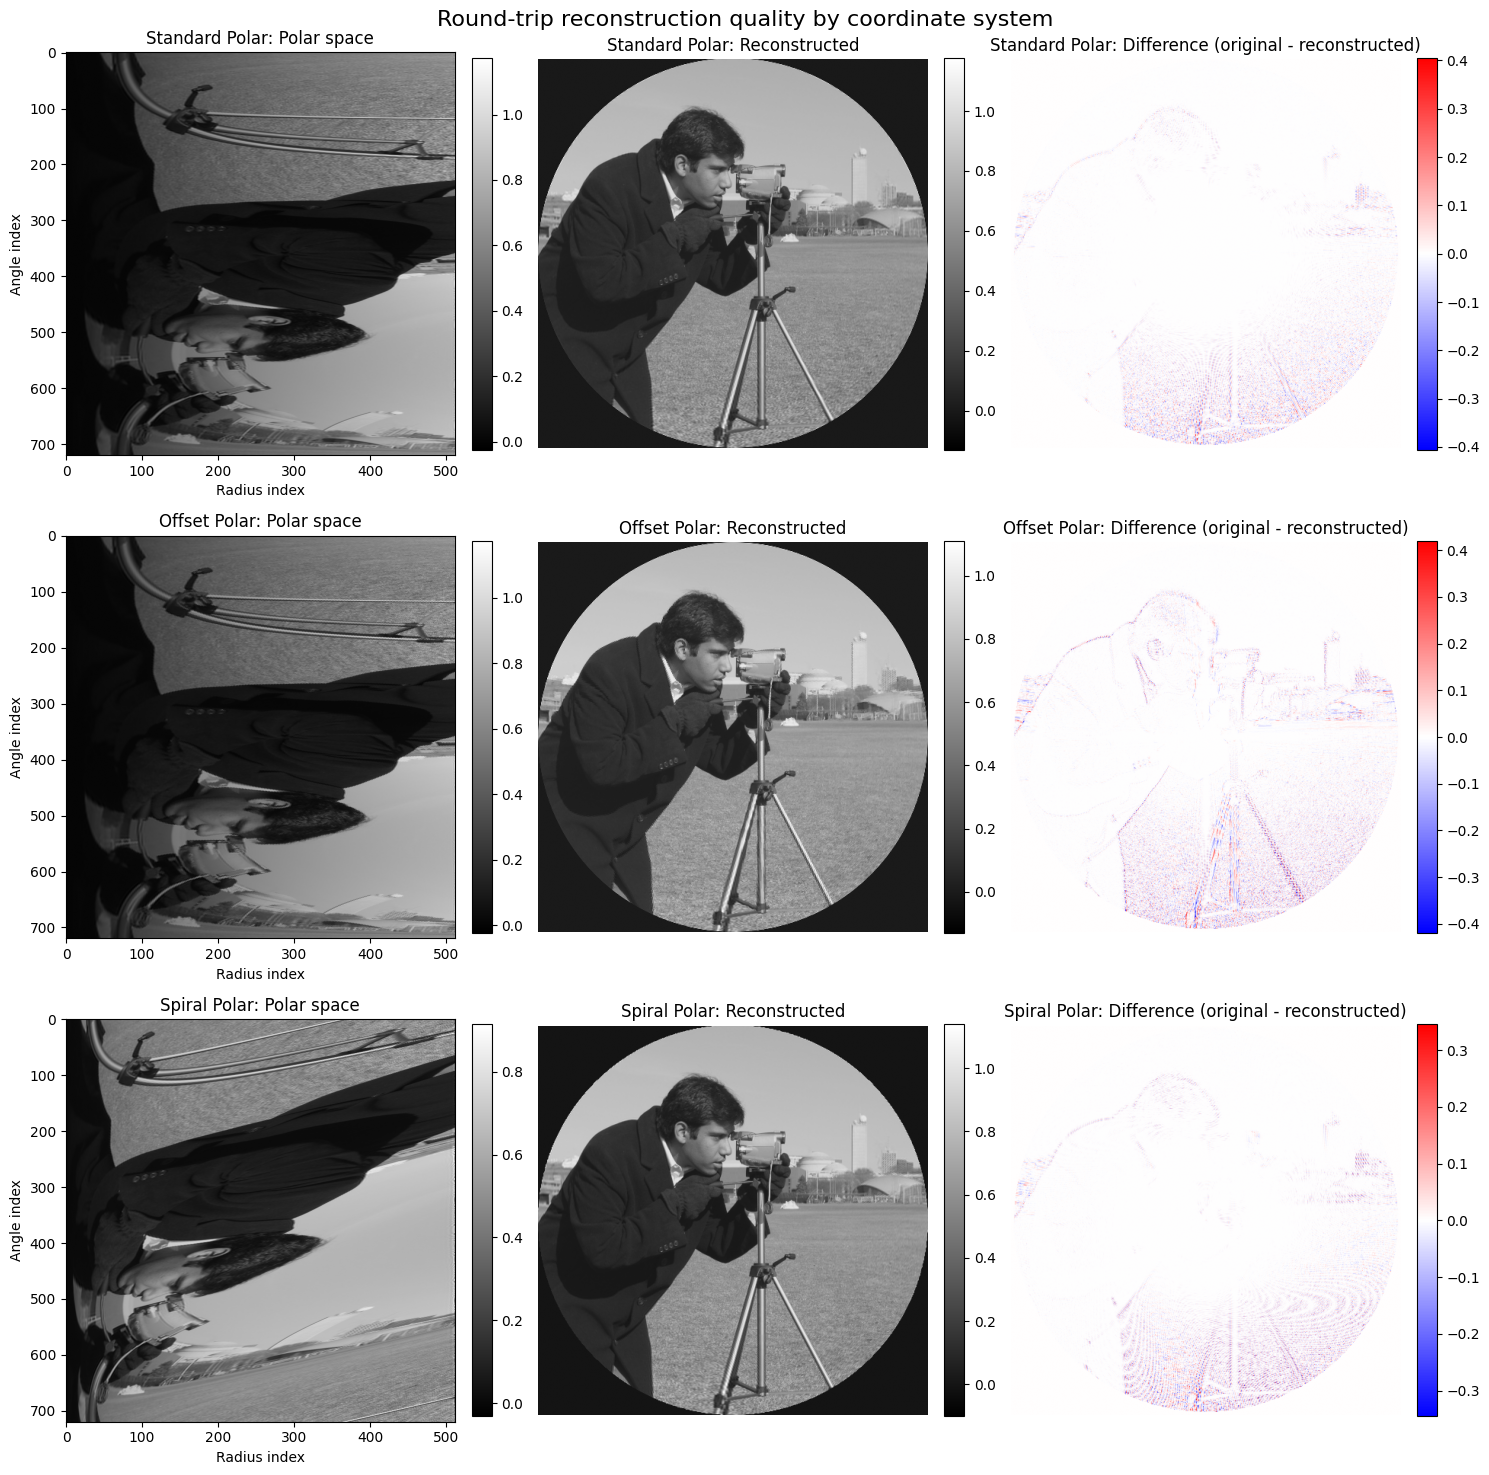

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for row, name in enumerate(transforms):
    polar_image = polar_images[name]
    reconstructed = reconstructions[name]
    diff = differences[name]
    max_diff = np.abs(diff).max()

    im0 = axes[row, 0].imshow(polar_image, cmap="gray", aspect="auto")
    axes[row, 0].set_title(f"{name}: Polar space")
    axes[row, 0].set_xlabel("Radius index")
    axes[row, 0].set_ylabel("Angle index")
    plt.colorbar(im0, ax=axes[row, 0], fraction=0.046, pad=0.04)

    im1 = axes[row, 1].imshow(reconstructed, cmap="gray")
    axes[row, 1].set_title(f"{name}: Reconstructed")
    axes[row, 1].axis("off")
    plt.colorbar(im1, ax=axes[row, 1], fraction=0.046, pad=0.04)

    im2 = axes[row, 2].imshow(diff, cmap="bwr", vmin=-max_diff, vmax=max_diff)
    axes[row, 2].set_title(f"{name}: Difference (original - reconstructed)")
    axes[row, 2].axis("off")
    plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

fig.suptitle("Round-trip reconstruction quality by coordinate system", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
print(f"{'System':<16}{'Mean |err|':>14}{'Max |err|':>14}{'Correlation':>14}")
for name in transforms:
    diff = differences[name]
    recon = reconstructions[name]
    corr = np.corrcoef(image.ravel(), recon.ravel())[0, 1]
    print(
        f"{name:<16}{np.mean(np.abs(diff)):>14.5f}"
        f"{np.max(np.abs(diff)):>14.5f}{corr:>14.5f}"
    )

System              Mean |err|     Max |err|   Correlation
Standard Polar         0.00603       0.40543       0.99629
Offset Polar           0.00998       0.41930       0.99461
Spiral Polar           0.00609       0.34525       0.99775
